## Analysis of alpha varying in LATB

In [2]:
import os
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:
base_path = '' # replace your results base path here
file_paths = [
    'alpha_1/results_alpha_1.csv',
    'alpha_5/results_alpha_5.csv',
    'alpha_10/results_alpha_10.csv',
    'alpha_15/results_alpha_15.csv',
    'alpha_20/results_alpha_20.csv',
    'alpha_40/results_alpha_40.csv',
    'alpha_50/results_alpha_50.csv',
    'alpha_500/results_alpha_500.csv',
    'no_latb/results_no_latb.csv'
]
alphas = [1, 5, 10, 15, 20, 40, 50, 500, 0]
dfs = []

for i, file_path in enumerate(file_paths):
    df = pd.read_csv(
        os.path.join(base_path, file_path)
    )
    df['alpha'] = alphas[i]
    dfs.append(df)

all_df = pd.concat(dfs).sort_values(by=['lang_code'])

In [3]:
def define_resource_level(lang_code):
    if (lang_code == 'ru') or (lang_code == 'zh') or (lang_code == 'ja') or (lang_code == 'fr') or (lang_code == 'en'):
        return 'HRL'
    elif (lang_code == 'ko') or (lang_code == 'th') or (lang_code == 'hi') or (lang_code == 'ar'):
        return 'MRL'
    else:
        raise NotImplementedError

In [4]:
all_df['resource_level'] = df['lang_code'].apply(define_resource_level)

In [5]:
def lineplot_by_lang_group(df, x, y):
    plt.rcParams["figure.figsize"] = (9,3)
    ax = sns.lineplot(df, x=x, y=y, hue='lang_code', marker="o", markersize=4, markeredgewidth=0)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.title(f"{x} vs. {y}")
    plt.show()

def lineplot_by_lang_group_shrink_x(df, x, y):
    plt.rcParams["figure.figsize"] = (3,6)
    ax = sns.lineplot(df, x=x, y=y, hue='lang_code', marker="o", markersize=4, markeredgewidth=0)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.title(f"{x} vs. {y}")
    plt.xlim([0, 50])
    plt.show()

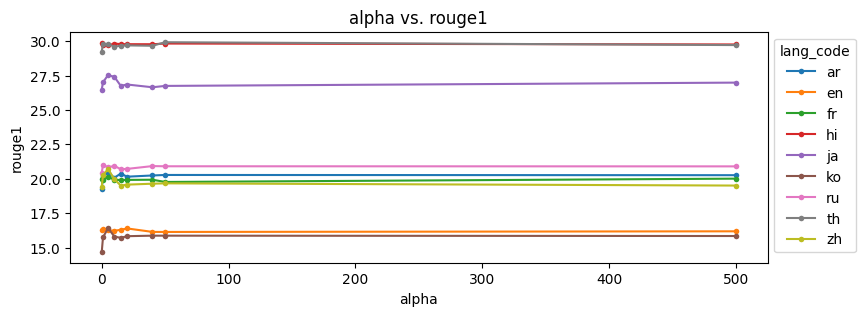

In [6]:
lineplot_by_lang_group(all_df, 'alpha', 'rouge1')

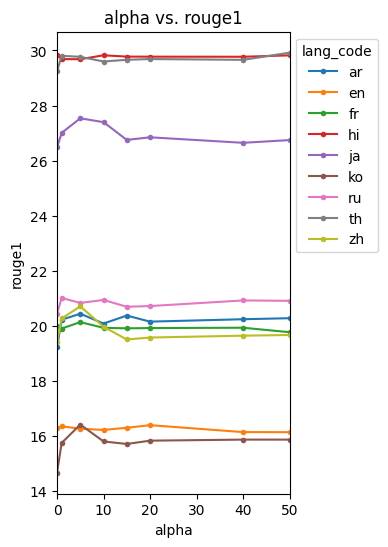

In [7]:
lineplot_by_lang_group_shrink_x(all_df, 'alpha', 'rouge1')

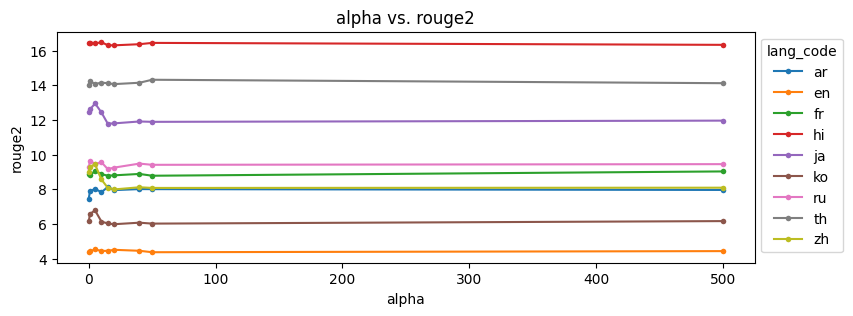

In [8]:
lineplot_by_lang_group(all_df, 'alpha', 'rouge2')

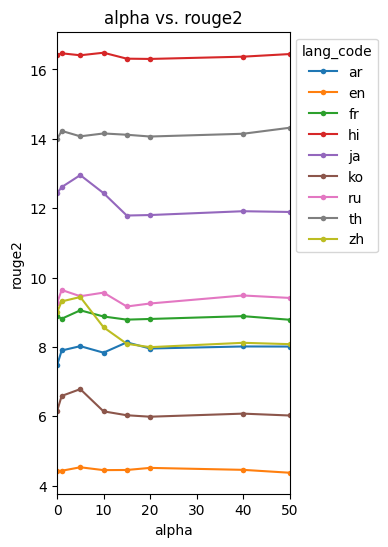

In [9]:
lineplot_by_lang_group_shrink_x(all_df, 'alpha', 'rouge2')

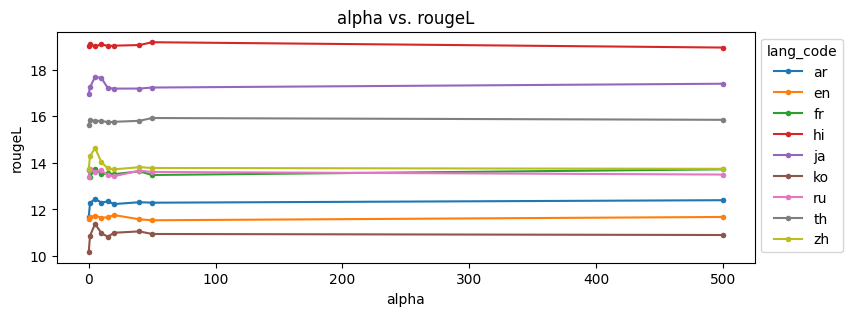

In [10]:
lineplot_by_lang_group(all_df, 'alpha', 'rougeL')

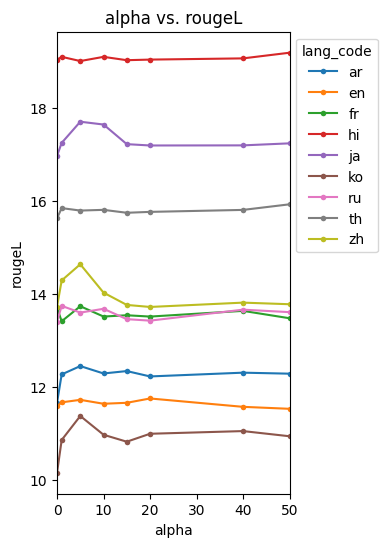

In [11]:
lineplot_by_lang_group_shrink_x(all_df, 'alpha', 'rougeL')

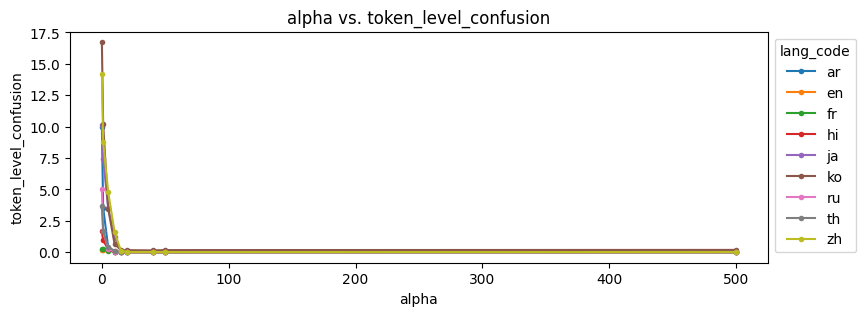

In [12]:
lineplot_by_lang_group(all_df, 'alpha', 'token_level_confusion')

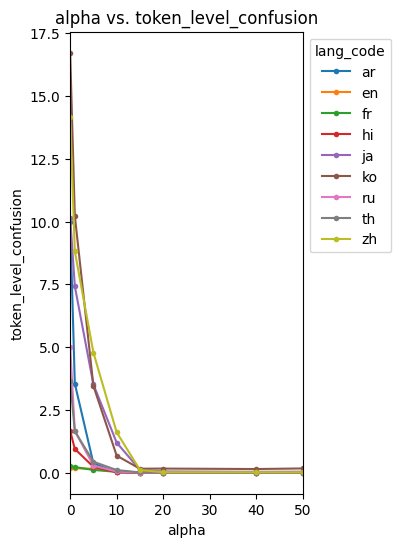

In [13]:
lineplot_by_lang_group_shrink_x(all_df, 'alpha', 'token_level_confusion')

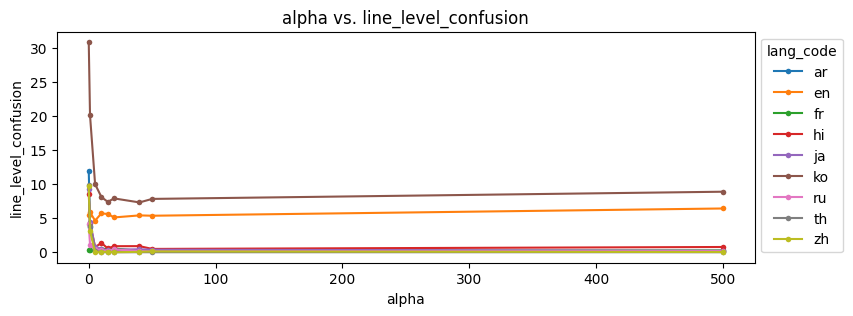

In [14]:
lineplot_by_lang_group(all_df, 'alpha', 'line_level_confusion')

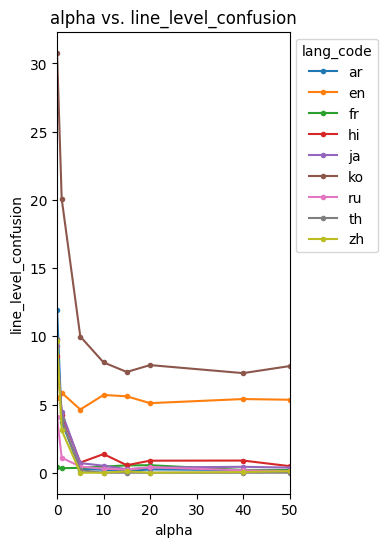

In [15]:
lineplot_by_lang_group_shrink_x(all_df, 'alpha', 'line_level_confusion')

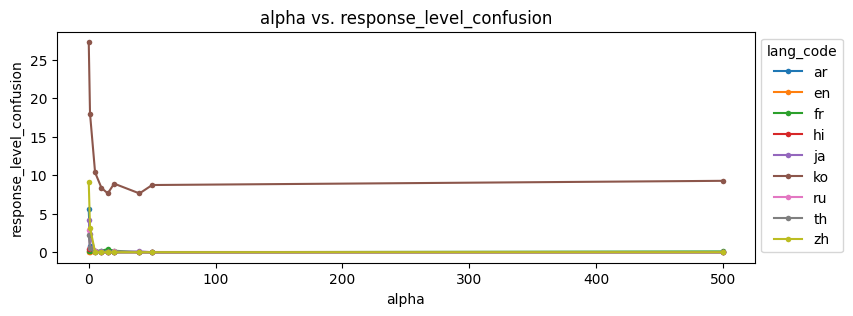

In [16]:
lineplot_by_lang_group(all_df, 'alpha', 'response_level_confusion')

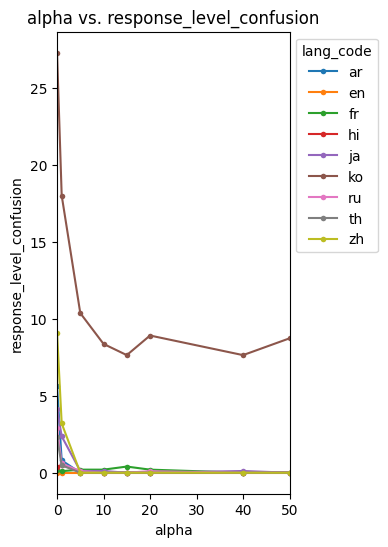

In [17]:
lineplot_by_lang_group_shrink_x(all_df, 'alpha', 'response_level_confusion')

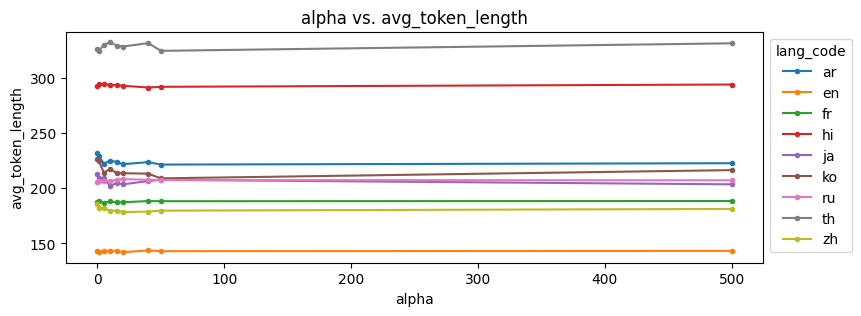

In [18]:
lineplot_by_lang_group(all_df, 'alpha', 'avg_token_length')

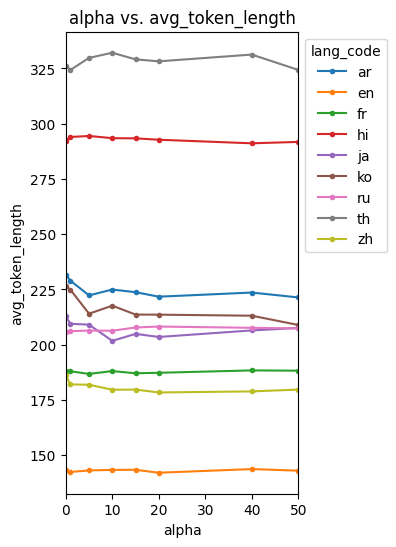

In [19]:
lineplot_by_lang_group_shrink_x(all_df, 'alpha', 'avg_token_length')

### Does LATB improve more on languages that confused more?

In [ ]:
def lang_confusion_rate_vs_metric(lang_confusion_metric, metric):
    max_rougeL_by_lang = all_df[['lang_code', metric]].groupby('lang_code').max()
    max_rougeL_by_lang = max_rougeL_by_lang.rename(columns={metric: f'max_{metric}'})
    no_latb_df = all_df[all_df['alpha'] == 0]
    rougeL_no_latb = no_latb_df[['lang_code', 'resource_level', metric, lang_confusion_metric]].set_index('lang_code')

    main_df = rougeL_no_latb.join(max_rougeL_by_lang)
    main_df['percent_improve'] = (main_df[f'max_{metric}'] - main_df[metric]) / main_df[metric] * 100
    
    return main_df

/tmp/ipykernel_3618/3424433293.py:23: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


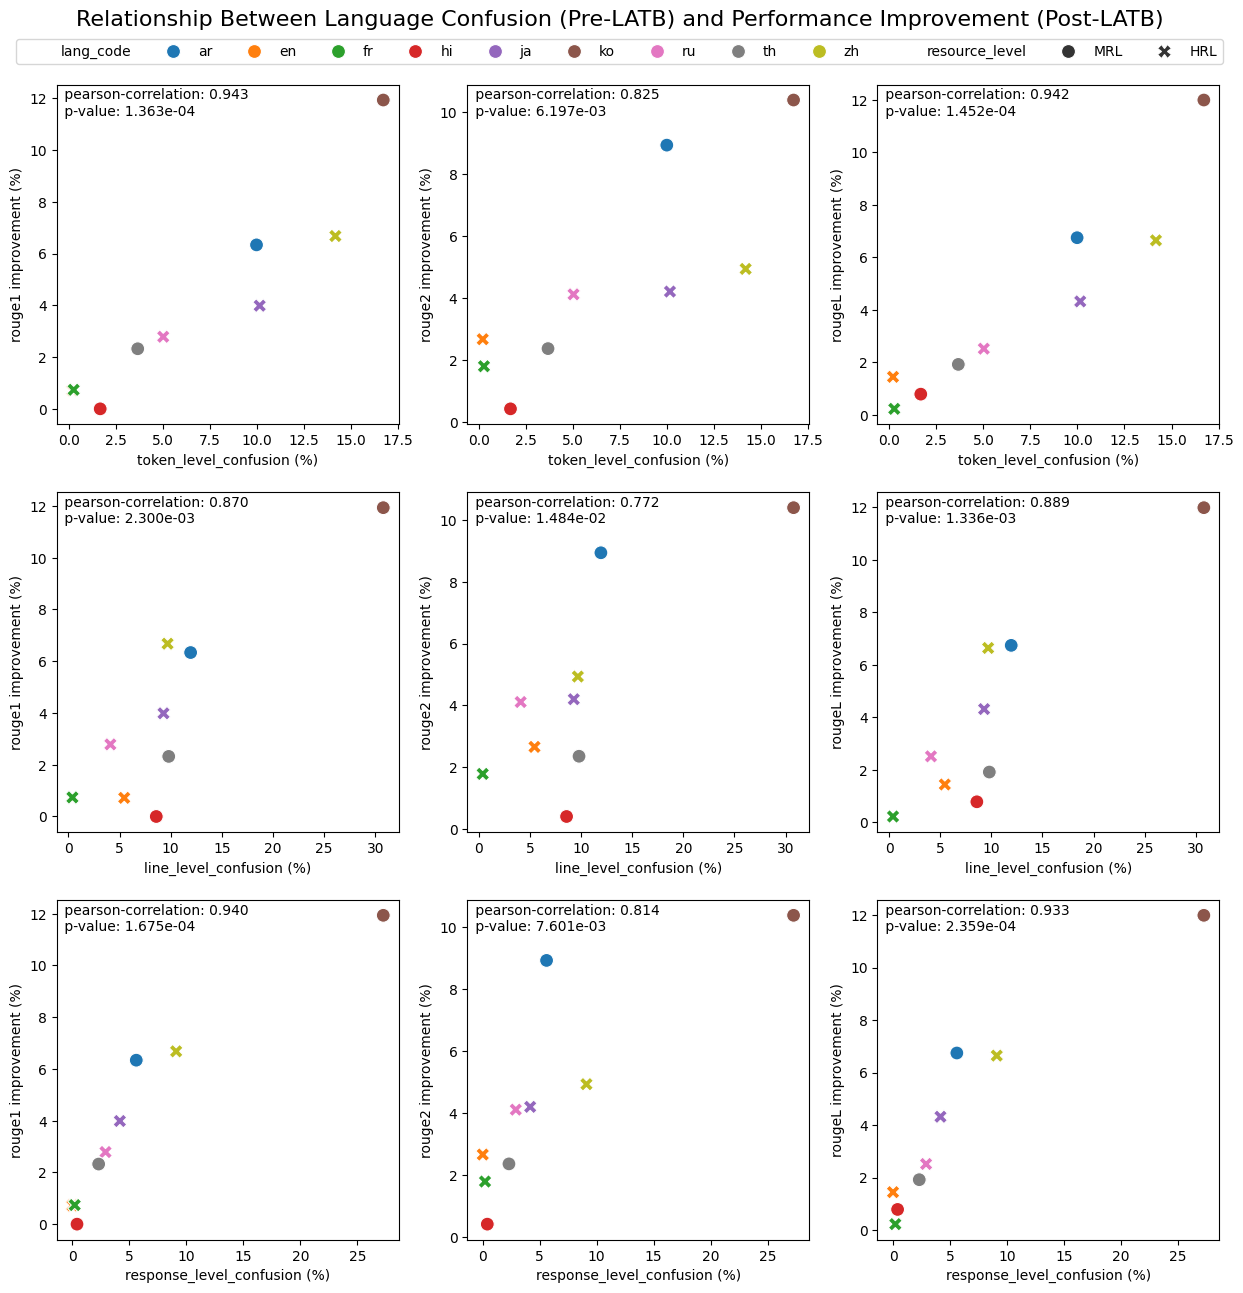

In [21]:
plt.rcParams["figure.figsize"] = (15, 15)
f, axes = plt.subplots(3, 3)
i = 0
for lc_metric in ['token_level_confusion', 'line_level_confusion', 'response_level_confusion']:
    for metric in ['rouge1', 'rouge2', 'rougeL']:
        df = lang_confusion_rate_vs_metric(lc_metric, metric)
        pearson = pearsonr(df[lc_metric], df['percent_improve'])
        ax = sns.scatterplot(df, x=lc_metric, y='percent_improve', hue='lang_code', style="resource_level", s=100, ax=axes[i//3, i%3])
        ax.get_legend().remove()
        ax.set_xlabel(f"{lc_metric} (%)")
        ax.set_ylabel(f"{metric} improvement (%)")
        plt.text(
            .01, .99, " pearson-correlation: {:.3f}\n p-value: {:.3e}".format(pearson.statistic, pearson.pvalue), 
            ha='left', va='top', transform=ax.transAxes
        )
        i += 1
lines, labels = ax.get_legend_handles_labels()
plt.legend(
    lines, labels, loc = 'upper center', bbox_to_anchor = (0, -0.085, 1, 1),
    bbox_transform = plt.gcf().transFigure, ncol=20
)
plt.suptitle("Relationship Between Language Confusion (Pre-LATB) and Performance Improvement (Post-LATB)", y=0.93, fontsize=16)
plt.tight_layout()
plt.show()